# Identificar Patrones

Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.

Delante de ti hay datos que se remontan a 2016. Imaginemos que es diciembre de 2016 y estás planeando una campaña para 2017.

### Inicialización

In [1]:
#Cargar librerias
from scipy import stats as st
from matplotlib import pyplot as plt
from math import factorial
import numpy as np
import pandas as pd
import seaborn as sns

### Cargar datos ###

In [2]:
games = pd.read_csv('datasets/P6/games.csv')

### Preparar Datos ###

In [3]:
#Imprimir información general de los datos
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
#Imprimir primeras filas para tener una idea de los datos
print(games.head())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


### Corregir datos ##

In [5]:
#Cambiaremos los nombres de las columnas a minúsculas
corrected_names = []
for name in games.columns:
    lowered_name = name.lower()
    corrected_names.append(lowered_name)
games.columns = corrected_names

print(games.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score user_score rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


In [6]:
#Cambiamos el tipo de dato de la columna 'user_score' de object a float y los valores como tbd los trataremos como nulos 
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


Por ahora mantendremos los demas datos como se encruentran ya que reemplazar o eliminar los valores nulos podría sesgar nuestros datos. Muchos de estos valores asentes pueden deberse a que aún no existen los datos, a que algunos videojuegos son muy antiguos y no se tienen datos completos de ellos o a que simplemente no se ha actulizado la información.

### Enriquecer datos ###

In [7]:
#Agregaremos una nueva columna a la tabla con el valor de las ventas totales para las 3 regiones excluyendo other_sales
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales']
print(games.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
1      3.58      6.81         0.77           NaN         NaN    NaN   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         2.95          80.0         8.0      E   
4      8.89     10.22         1.00           NaN         NaN    NaN   

   total_sales  
0        74.09  
1        39.47  
2        32.23  
3        29.82  
4

### Revisión de los datos ###

In [8]:
#Veamos cuantos juegos fueron lanzados en los diferentes años
print(games['year_of_release'].value_counts().sort_index())

year_of_release
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      62
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     350
2001.0     482
2002.0     829
2003.0     775
2004.0     762
2005.0     939
2006.0    1006
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: count, dtype: int64


A medida que pasan los años vamos obteniendo información acerca de más videojuegos, puede deberse a un aumento en su popularidad y así mismo a un aumento en su producción, sin embargo para los últimos años disminuye el número de juegos, puede ser que no esté actualizada la tabla o que haya disminuido la producción de videojuegos en esos años, igualmente hay que tener en cuenta que existen valores ausentes en el lanzamiento de los videojuegos que podrían pertenecer a estos años.

In [9]:
#Busquemos las plataformas con las mayóres ventas totales
sales_by_platform = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(sales_by_platform)

platform
PS2     1062.33
X360     885.66
Wii      828.44
PS3      803.97
DS       746.86
PS       689.95
GBA      310.12
PS4      265.79
PSP      252.63
XB       249.02
GB       247.26
NES      245.74
3DS      245.64
PC       237.14
N64      214.30
SNES     196.82
GC       193.75
XOne     145.05
2600      96.07
WiiU      76.24
PSV       47.61
SAT       33.52
GEN       29.80
DC        15.68
SCD        1.81
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


Podemos ver que las plataformas con las mayores ventas totales son PS2, X360, Wii, PS3, DS y PS, en ese orden.

In [10]:
#Veamos las ventas de estas plataformas por año
top_platforms = ['PS2', 'X360', 'Wii', 'PS3', 'DS', 'PS']
platform_filtered_df = games[games['platform'].isin(top_platforms)]

pivot_platform = platform_filtered_df.pivot_table(index='year_of_release',
                                                 columns='platform',
                                                 values='total_sales',
                                                 aggfunc='sum')

print(pivot_platform)

platform             DS      PS     PS2     PS3     Wii    X360
year_of_release                                                
1985.0             0.02     NaN     NaN     NaN     NaN     NaN
1994.0              NaN    5.63     NaN     NaN     NaN     NaN
1995.0              NaN   34.00     NaN     NaN     NaN     NaN
1996.0              NaN   89.16     NaN     NaN     NaN     NaN
1997.0              NaN  128.30     NaN     NaN     NaN     NaN
1998.0              NaN  160.44     NaN     NaN     NaN     NaN
1999.0              NaN  136.61     NaN     NaN     NaN     NaN
2000.0              NaN   91.09   35.59     NaN     NaN     NaN
2001.0              NaN   33.42  149.65     NaN     NaN     NaN
2002.0              NaN    6.31  183.66     NaN     NaN     NaN
2003.0              NaN    1.93  163.62     NaN     NaN     NaN
2004.0            15.91     NaN  171.96     NaN     NaN     NaN
2005.0           119.34     NaN  141.51     NaN     NaN    7.61
2006.0           111.64     NaN   89.18 

De acuerdo a esto, 3 de las plataformas con más ventas(DS, PS, PS2) ya no tienen relevancia y sus usuarios han migrado a plataformas más modernas, esto asumiendo que los valores nulos indican que no existen ventas reportadas de cada plataforma en los años especificados. Sin embargo las 3 plataformas que aun presentan ventas a 2016(PS3, Wii, X360) se encuentran en declive y han tenido una disminución de sus ventas significativamente despues de alcanzar su pico máximo.


In [11]:
#Veamos cuantos años de vigencia tienen las plataformas y cuanto tiempo tardan en surgir las nuevas
privot_platform_showup =  games.pivot_table(index='year_of_release',
                                            columns='platform', 
                                            values='total_sales',
                                            aggfunc='sum')
print(privot_platform_showup)

platform          2600   3DO    3DS    DC      DS     GB    GBA     GC    GEN  \
year_of_release                                                                 
1980.0           11.26   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1981.0           35.36   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1982.0           28.57   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1983.0            5.78   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1984.0            0.27   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1985.0            0.45   NaN    NaN   NaN    0.02    NaN    NaN    NaN    NaN   
1986.0            0.67   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1987.0            1.93   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1988.0            0.73   NaN    NaN   NaN     NaN   1.40    NaN    NaN    NaN   
1989.0            0.62   NaN    NaN   NaN     NaN  63.57    NaN    NaN    NaN   
1990.0             NaN   NaN

Vemos que la plataformas más populares tienden a tener un tiempo de vigencia de entre 10 y 11 años, así mismo vemos que las nuevas plataformas tienden a surgir antes de que finalice la vida util de las anteriores en plazos de entre 6 y 8 años despues del nacimiento de la anterior. Podemos entender que plataformas como WiiU aun puede tener un par de años de ventas y la XOne aún podria tener 5 años de ventas y aún no haber alcanzado su punto máximo de ventas.

Basado en lo que vimos amnteriormente tomaremos datos de un periodo de 10 años desde 2007.

In [12]:
#filtremos nuestra tabla con los datos de los últimos 10 años y veamos las ventas totales por año de cada plataforma
last_ten_years = games[games['year_of_release'] > 2006]

pivot_last_ten_years = last_ten_years.pivot_table(index='year_of_release',
                                                  columns='platform',
                                                  values='total_sales',
                                                  aggfunc='sum')

print(pivot_last_ten_years)

platform           3DS    DC      DS   GBA    GC     PC    PS2     PS3  \
year_of_release                                                          
2007.0             NaN  0.02  135.85  3.35  0.27   8.98  52.30   62.48   
2008.0             NaN  0.04  134.37   NaN   NaN  10.43  34.59  101.78   
2009.0             NaN   NaN  110.99   NaN   NaN  14.92  16.24  113.08   
2010.0             NaN   NaN   79.48   NaN   NaN  21.31   4.44  121.36   
2011.0           58.80   NaN   24.30   NaN   NaN  29.70   0.35  135.22   
2012.0           48.77   NaN   10.42   NaN   NaN  20.41    NaN   90.87   
2013.0           53.97   NaN    1.42   NaN   NaN  11.27    NaN   95.85   
2014.0           41.75   NaN     NaN   NaN   NaN  12.38    NaN   40.88   
2015.0           26.75   NaN     NaN   NaN   NaN   7.93    NaN   14.70   
2016.0           14.50   NaN     NaN   NaN   NaN   4.89    NaN    3.23   

platform            PS4    PSP    PSV     Wii   WiiU    X360    XB   XOne  
year_of_release                    

En el año 2016 las plataformas lideres en ventasy aún con potencial de crecimiento y más rentables son 'PS4', 'XOne' y '3DS', en ese orden. Reducen sus ventas y empiezan a desaparecer las plataformas 'PC', 'PS3', 'PSV', 'Wii' y 'X360'. 


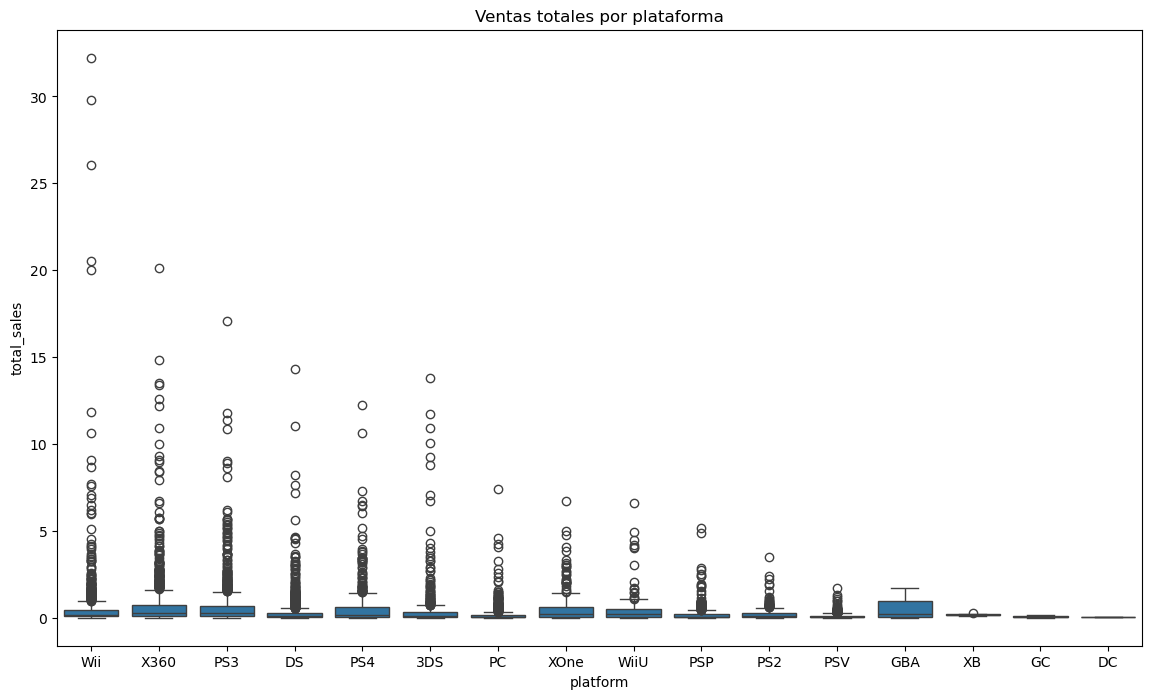

In [13]:
#Creemos un gráfico que muestre las ventas totales de todos los juegos por plataforma para los últimos 10 años
plt.figure(figsize=(14,8))
sns.boxplot(data=last_ten_years,
            x='platform',
            y='total_sales')

plt.title('Ventas totales por plataforma')
plt.show()

El gráfico nos muestra diferencias cortas en las medianas, sin embargo se presentan muchos valores atípicos en las plataformas con más ventas lo que indica que existen videojuegos que alcanzan ventas gigantes en comparación con videojuegos promedio, esto hace que las ventas totales se disparen debido en su mayoria a videojuegos especialmente populares.

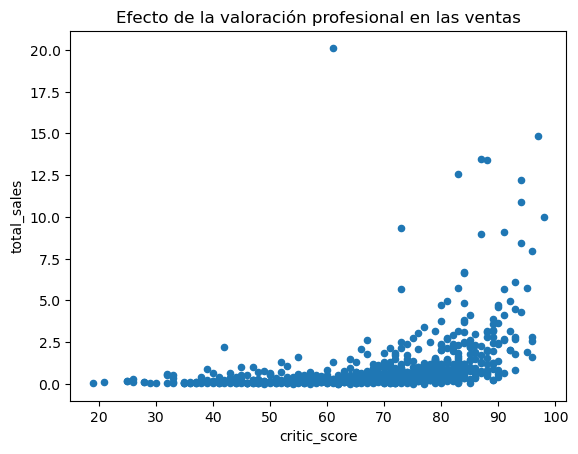

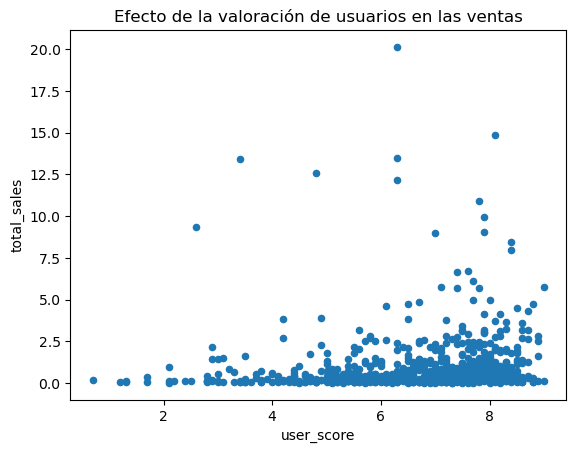

In [14]:
#Veamos como afectan las reseñas a las ventas de una de las plataformas más populares: X360
x360_last_ten_years = last_ten_years[last_ten_years['platform'] == 'X360']

x360_last_ten_years.plot(kind='scatter', x='critic_score', y='total_sales', title='Efecto de la valoración profesional en las ventas')
x360_last_ten_years.plot(kind='scatter', x='user_score', y='total_sales', title='Efecto de la valoración de usuarios en las ventas')
plt.show()



In [15]:
#Veamos la correlación entre las valoraciones y las ventas
print('Correlación entre la valoración profesional y las ventas totales: \n', x360_last_ten_years[['critic_score', 'total_sales']].corr())
print()
print('Correlación entre la valoración de los usuarios y las ventas totales: \n', x360_last_ten_years[['user_score', 'total_sales']].corr())

Correlación entre la valoración profesional y las ventas totales: 
               critic_score  total_sales
critic_score      1.000000     0.395627
total_sales       0.395627     1.000000

Correlación entre la valoración de los usuarios y las ventas totales: 
              user_score  total_sales
user_score     1.000000     0.113649
total_sales    0.113649     1.000000


Se evidencia que no existe una relación completamente marcada entre las valoraciones y las ventas, sin embargo como podemos ver en las gráficas y los valores de correlación hay una mayor tendencia de los usuarios a comprar los videojuegos con buenas valoraciones profesionales y de usuarios, siendo más clara para la valoración profesional la tendencia, sin embargo esto solo se cumple para algunos videojuegos y no es la regla general para el videojuego promedio.

In [16]:
#Veamos como se comportan algunos de los videojuegos con mejor valoracion y mayores ventas de X360 en otras plataformas, si existen:
x360_last_ten_years_top_games = x360_last_ten_years[(x360_last_ten_years['critic_score'] > 90) & (x360_last_ten_years['total_sales'] > 10)]
#print(x360_last_ten_years_top_games)

games_to_check = []
for name in x360_last_ten_years_top_games['name']:
    games_to_check.append(name)

#print(games_to_check)

game_result_check = last_ten_years.query("name in @games_to_check")
#print(game_result_check)

pivot_games_to_check = game_result_check.pivot_table(index='platform',
                                                     columns='name',
                                                     values='total_sales',
                                                     aggfunc='sum')
print(pivot_games_to_check)

name      Call of Duty: Modern Warfare 2  Grand Theft Auto V  Halo 3
platform                                                            
PC                                  0.80                1.08     NaN
PS3                                 9.01               17.09     NaN
PS4                                  NaN               10.65     NaN
X360                               12.19               14.86   10.91
XOne                                 NaN                5.00     NaN


Tomamos 3 de los juegos mejor valorados y de mayores ventas de la plataforma X360, estos fueron 'Call of Duty: Modern Warfare 2', 'Grand Theft Auto V' y 'Halo 3'. Basados en los datos de 10 años los juegos tuvieron buenas ventas y fueron similares en las plataformas en las cuales podian jugarse.

Empezando con Call of Duty: Modern Warfare 2 salió para las plataformas X360 con ventas de 12.19 y PS3 con ventas de 9.01, tambien aparece para PC con ventas de 0.80 esto puede deberse a que en general no es muy usada la PC para juegos o a que su popularidad en dicha plataforma fue anterior a los 10 años. El videojuego Grand Theft Auto V es el que muestra una popularidad superlativa en todas las plataformas para las que salió a la venta con ventas superiores a los 10 en PS3, PS4 y X360, así mismo muestra ventas de 1.08 para PC que pueden deberse a las mismas condiciones del anterior videojuego, y ventas de 5 en XOne sin embargo en este último caso es posible que el videojuego aún no haya alcanzado su máximo de ventas ya que la plataforma es aún nueva y se encuentra aumentando su popularidad. Finalmente para el videojuego Halo 3 tenemos información unicamente  para la plataforma X360 y es posible que sea un juego exclusivo de la misma.

In [17]:
#Veamos como se comportan las ventas para cada genero
print(last_ten_years.groupby('genre')['total_sales'].sum().sort_values(ascending=False))

genre
Action          924.13
Shooter         597.73
Sports          575.63
Misc            435.57
Role-Playing    428.63
Racing          229.64
Platform        206.95
Simulation      181.74
Fighting        145.81
Adventure       118.64
Puzzle           72.84
Strategy         62.91
Name: total_sales, dtype: float64


Vemos una clara predominancia de los géneros Role-Playing, Misc, Sports, Shooter y el más rentable de todos muy por encima de los demás el género Action con ventas totales de 924.13, una diferencia de 326.4 con el segúndo que es el género Shooter.

### Perfil por región ###

In [18]:
#Veamos las plataformas principales de cada región
top_platforms_na = last_ten_years.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
print('Top 5 de plataformas en NA: \n', top_platforms_na.head())

Top 5 de plataformas en NA: 
 platform
X360    553.68
Wii     416.01
PS3     381.29
DS      273.98
PS4     108.74
Name: na_sales, dtype: float64


In [19]:
top_platforms_eu = last_ten_years.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
print('Top 5 de plataformas en EU: \n',top_platforms_eu.head())

Top 5 de plataformas en EU: 
 platform
PS3     319.83
X360    257.05
Wii     214.70
PS4     141.09
DS      119.92
Name: eu_sales, dtype: float64


In [20]:
top_platforms_jp = last_ten_years.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
print('Top 5 de plataformas en JP:\n', top_platforms_jp.head())

Top 5 de plataformas en JP:
 platform
DS     102.93
3DS    100.62
PS3     78.33
PSP     66.24
Wii     59.13
Name: jp_sales, dtype: float64


In [21]:
#para saber el porcentaje que aporta cada región al total de ventas veamos las ventas totales de cada plataforma
top_platforms_regions_list = ['X360', 'Wii', 'PS3', 'DS', 'PS4', '3DS', 'PSP']
top_platforms_regions_df = last_ten_years[last_ten_years['platform'].isin(top_platforms_regions_list)].groupby('platform')['total_sales'].sum()
print(top_platforms_regions_df.sort_values(ascending=False))

platform
X360    821.55
PS3     779.45
Wii     689.84
DS      496.83
PS4     265.79
3DS     244.54
PSP     159.03
Name: total_sales, dtype: float64


El top 5 de plataformas se repite para NA y UE aunque en orden diferente las plataformas X360, Wii, PS3, DS, PS4; así mismo para JP salen del top las plataformas X360 y PS4 siendo sustituidas por 3DS y PSP.

-Las ventas de X360 en NA son de 553.68 representando el 67.39% de las ventas totales de esta plataforma y se encuentra en el primer lugar, mientras que las ventas de la misma plataforma en EU son de 357.05 y representan un 31.28% y se encuentra en el segundo lugar.

-Las ventas de Wii en NA son de 416.01 representando el 60.3% de las ventas totales de esta plataforma y se encuentra en el segundo lugar, mientras que las ventas de la misma plataforma en EU son de 214.70 y representan un 31.12% y se encuentra en el tercer lugar. Así mismo en JP las ventas de esta plataforma son de 59.13 representando el 8.5% y estando en el quinto lugar de la región.

-Las ventas de PS3 en NA son de 381.29 representando el 48.91% de las ventas totales de esta plataforma y se encuentra en el tercer lugar, mientras que las ventas de la misma plataforma en EU son de 319.83 y representan un 41.03% y se encuentra en el primer lugar. Así mismo en JP las ventas de esta plataforma son de 78.33 representando el 10% y estando en el tercer lugar de la región.

-Las ventas de DS en NA son de 273.98 representando el 55.14% de las ventas totales de esta plataforma y se encuentra en el cuarto lugar, mientras que las ventas de la misma plataforma en EU son de 119.92 y representan un 24.13% y se encuentra en el quinto lugar. Así mismo en JP las ventas de esta plataforma son de 102.93 representando el 20.71% y estando en el primer lugar de la región.

-Las ventas de PS4 en NA son de 108.74 representando el 40.91% de las ventas totales de esta plataforma y se encuentra en el quinto lugar, mientras que las ventas de la misma plataforma en EU son de 141.09 y representan un 53.08% y se encuentra en el cuarto lugar.

-Las ventas de 3DS en JP son de 100.62 representando el 42.14% de las ventas totales de esta plataforma y se encuentra en el segundo lugar de esta región.

-Las ventas de PSP en JP son de 66.24 representando el 41.65% de las ventas totales de esta plataforma y se encuentra en el cuarto lugar de esta región.

In [22]:
#Veamos los géneros principales de cada región
top_genres_na = last_ten_years.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
print('Top 5 de géneros en NA: \n', top_genres_na.head())

Top 5 de géneros en NA: 
 genre
Action          492.17
Shooter         350.11
Sports          323.86
Misc            259.16
Role-Playing    175.41
Name: na_sales, dtype: float64


In [23]:
top_genres_eu = last_ten_years.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
print('Top 5 de géneros en EU: \n', top_genres_eu.head())

Top 5 de géneros en EU: 
 genre
Action     335.67
Shooter    230.16
Sports     211.49
Misc       127.62
Racing     104.63
Name: eu_sales, dtype: float64


In [24]:
top_genres_jp = last_ten_years.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)
print('Top 5 de géneros en JP: \n', top_genres_jp.head())

Top 5 de géneros en JP: 
 genre
Role-Playing    150.55
Action           96.29
Misc             48.79
Sports           40.28
Adventure        26.91
Name: jp_sales, dtype: float64


Nuevamente vemos que los gustos en NA y EU son muy similares y que algunos generos se comparten en las tres regiones pero que JP muestra gustos marcados que difieren un poco de las demás regiones. El género Action es claramente el más popular, ocupa la primera posición tanto en NA y en EU, además ocupa la segunda pisición en JP. En JP el género más popular el el Role-Playing ocupando el primer lugar, aparece tambien en la posición número cinco en NA pero no alcanza el top  en EU. Shooter, Sports y Misc ocupan posiciones privilegiadas en los segundos terceros o cuartos puestos repartidos en las regiones, sin embargo JP no incluye el género Shooter. Cierran los géneros más vendidos el Racing en EU para la quinta posición y Adventure en JP en la misma posición para un total de 7 géneros repartidos en el top 5 de las tres regiones.

In [25]:
#Veamos si el ESRB afecta de algún modo las ventas en cada región

print('Ventas NA por ESRB\n', last_ten_years.groupby('rating')['na_sales'].sum())

Ventas NA por ESRB
 rating
E       663.99
E10+    287.61
EC        1.32
M       546.55
RP        0.00
T       371.32
Name: na_sales, dtype: float64


In [26]:
print('Ventas EU por ESRB\n', last_ten_years.groupby('rating')['eu_sales'].sum())

Ventas EU por ESRB
 rating
E       393.08
E10+    162.75
EC        0.00
M       385.86
RP        0.03
T       217.89
Name: eu_sales, dtype: float64


In [27]:
print('Ventas JP por ESRB\n', last_ten_years.groupby('rating')['jp_sales'].sum())

Ventas JP por ESRB
 rating
E       95.06
E10+    31.91
EC       0.00
M       41.09
RP       0.00
T       74.74
Name: jp_sales, dtype: float64


Hay una clara tendencia maracada, vemos que las ventas totales para las tres regiones de distribuyen en primer lugar para las valoraciones E, seguidas de las valoraciones M para las regiones NA-EU y T para JP, en tercer lugar de ventas estan las clasificaciones T para NA-EU y M para JP. Esto podríadeberse a la amplitud de los grupos poblacionales de cada región que cumplen con la limitante de edad de cada clasificación sin embargo es indudable que hay una influencia clara de la clasificación en las ventas.

### Pruebas de hipótesis ###

1.Veamos si las clasificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales.
Ho: las clasificaciones promedios son iguales.
H1: las clasificaciones promedio son diferentes.

In [28]:
#Comprobemos la hipótesis nula
xone_df = last_ten_years[last_ten_years['platform'] == 'XOne']
pc_df = last_ten_years[last_ten_years['platform'] == 'PC']

alpha = 0.05
results = st.ttest_ind(xone_df['user_score'].dropna(), pc_df['user_score'].dropna())
print('Valor p: ', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

Valor p:  0.05554752084307562
No podemos rechazar la hipótesis nula


No existe certeza en que las calificaciones promedio de los usuarios para las plataformas XOne y PC sean diferentes, por tanto no podemos rechazar la hipótesis nulas Ho:  las clasificaciones promedio son iguales. Se utilizó este método y se eligió la hipótesis nula ya que queremos comparar la media de dos poblaciones.

2.Veamos si las clasificaciones promedio de los usuarios para los géneros Acción y Deportes son diferentes.
En este caso elegiremos 
Ho: las clasificaciones promedio son iguales.
H1: las clasificaciones promedio son diferentes.

In [29]:
#Comprobemos la hipótesis nula
action_df = last_ten_years[last_ten_years['genre'] == 'Action']
sports_df = last_ten_years[last_ten_years['genre'] == 'Sports']

alpha = 0.05
results = st.ttest_ind(action_df['user_score'].dropna(), sports_df['user_score'].dropna())
print('Valor p: ', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

Valor p:  1.0894514919563485e-12
Rechazamos la hipótesis nula


En este caso el resultado nos indica que podemos rechazar la hipótesis nula con certeza y por tanto concluir que las calificaciones promedio de los usuarios para los géneros Acción y Desportes son diferentes.. Se utilizó este método y se eligió la hipótesis nula ya que queremos comparar la media de dos poblaciones.

### Conclusión ###

Despues de analizados los resultados podemos concluir que para el año 2017 es altamente probable una alta popularidad para las plataformas XOne y PS4 que aún se encuentran en crecimiento. Se esperarían ventas altas en videojuegos puntuales de los géneros Action, Shooter, Sports y Role-Playing, especialmente en aquellos con clasificación ESRB de E y T, las buenas puntuaciones profecionales aumentarian un poco la tendencia de los usuarios a adquirir estos videojuegos. Finalmente para las plataformas 3DS y WiiU vemos que se encuentran en decrecimiento de ventas y/o popularidad y están llegando al final de su vida util por tanto esperariamos pronto el lanzamiento una nueva plataforma que las sustituya.